# 03 — Modelo Baseline: "Primer Disparo"

---

## Misión

Tu primer modelo **NO** tiene que ser perfecto — tiene que darte un **punto de referencia**.

Si solo dijeras "Benigno" para todo, acertarías el ~63%. ¿Puedes mejorar eso?

### ¿Qué es un baseline?

Es el modelo más tonto posible. El que no sabe nada. El que adivina.

**Si tu modelo "inteligente" no supera al baseline, algo está roto.**

### Estrategia

1. **Piso** → `DummyClassifier` (el que adivina)
2. **Lineal** → `LogisticRegression` (simple, interpretable)
3. **Ensemble** → `RandomForest` (muchos árboles, votan)
4. **Gradient Boosting** → `XGBoost` (árboles que aprenden de sus errores)

Cada uno más complejo que el anterior. Veamos si la complejidad paga.

## 1. Imports

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
COLOR_B = '#2ecc71'
COLOR_M = '#e74c3c'

print("Imports OK")

Imports OK


## 2. Cargar datos procesados

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
processed_dir = os.path.join(project_root, "data", "breast_cancer", "processed")

X_train = pd.read_parquet(os.path.join(processed_dir, "X_train.parquet"))
X_test = pd.read_parquet(os.path.join(processed_dir, "X_test.parquet"))
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet")).values.ravel()
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet")).values.ravel()

print(f"Train: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} muestras")
print(f"\nDistribución y_train: B={np.sum(y_train==0)}, M={np.sum(y_train==1)}")
print(f"Distribución y_test:  B={np.sum(y_test==0)}, M={np.sum(y_test==1)}")

Train: 455 muestras, 23 features
Test:  114 muestras

Distribución y_train: B=285, M=170
Distribución y_test:  B=72, M=42


## 3. DummyClassifier — El piso

Este modelo **siempre predice la clase mayoritaria**. No mira features, no aprende nada.

Si tu modelo real no supera esto, es inútil.

In [3]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
print(f"Accuracy del Dummy: {acc_dummy:.4f}")
print(f"\nEste es tu PISO: ~{acc_dummy*100:.0f}%")
print("Cualquier modelo que no supere esto es peor que adivinar.")

Accuracy del Dummy: 0.6316

Este es tu PISO: ~63%
Cualquier modelo que no supere esto es peor que adivinar.


In [4]:
print(classification_report(y_test, y_pred_dummy, target_names=['Benigno', 'Maligno']))

              precision    recall  f1-score   support

     Benigno       0.63      1.00      0.77        72
     Maligno       0.00      0.00      0.00        42

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114



/home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/.venv/lib/python3.12/site-pac

Observa: recall para Maligno es **0.00**. El Dummy nunca detecta cáncer. Inútil clínicamente.

---

## 4. Logistic Regression — Simple y poderosa

Traza una línea (o hiperplano) que separa las dos clases. Rápida, interpretable.

`class_weight='balanced'` le dice: "los malignos son menos, pero importan igual".

In [5]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

# Validación cruzada estratificada: 5 folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(lr, X_train, y_train, cv=skf, scoring='accuracy')

print("Scores por fold:", [f"{s:.4f}" for s in cv_scores_lr])
print(f"\nCV Accuracy: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

Scores por fold: ['0.9560', '0.9780', '1.0000', '0.9670', '0.9670']

CV Accuracy: 0.9736 ± 0.0149


In [6]:
# Entrenar modelo final con todo el train set
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression — Test Set ===")
print(classification_report(y_test, y_pred_lr, target_names=['Benigno', 'Maligno']))

=== Logistic Regression — Test Set ===
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



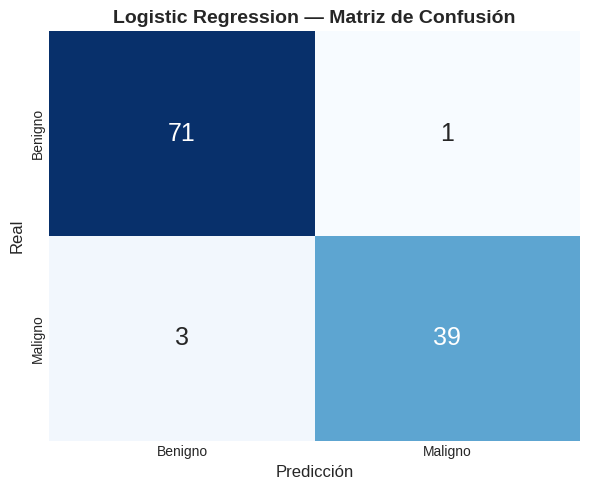

FP (sano → dicho cáncer): 1
FN (cáncer → dicho sano): 3  ← PELIGROSO


In [7]:
# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benigno', 'Maligno'],
    yticklabels=['Benigno', 'Maligno'],
    ax=ax, cbar=False,
    annot_kws={'size': 18}
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Logistic Regression — Matriz de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"FP (sano → dicho cáncer): {cm_lr[0, 1]}")
print(f"FN (cáncer → dicho sano): {cm_lr[1, 0]}  ← PELIGROSO")

---

## 5. Random Forest — El comité de árboles

100 árboles de decisión, cada uno entrenado con una muestra diferente. Votan.

Ventaja: captura relaciones no lineales. Desventaja: más difícil de interpretar.

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')

print("Scores por fold:", [f"{s:.4f}" for s in cv_scores_rf])
print(f"\nCV Accuracy: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

Scores por fold: ['0.9451', '1.0000', '0.9121', '0.9451', '0.9780']

CV Accuracy: 0.9560 ± 0.0303


In [9]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest — Test Set ===")
print(classification_report(y_test, y_pred_rf, target_names=['Benigno', 'Maligno']))

=== Random Forest — Test Set ===
              precision    recall  f1-score   support

     Benigno       0.95      1.00      0.97        72
     Maligno       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



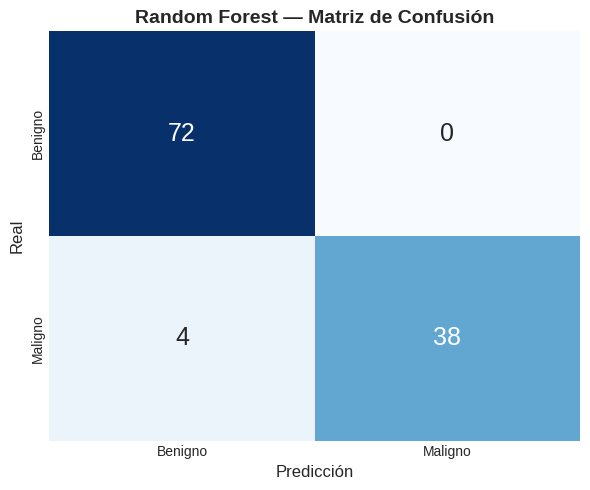

FP: 0
FN: 4  ← PELIGROSO


In [10]:
# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benigno', 'Maligno'],
    yticklabels=['Benigno', 'Maligno'],
    ax=ax, cbar=False,
    annot_kws={'size': 18}
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Random Forest — Matriz de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"FP: {cm_rf[0, 1]}")
print(f"FN: {cm_rf[1, 0]}  ← PELIGROSO")

### Feature Importance — ¿Qué le importa al bosque?

Random Forest nos dice cuánto contribuye cada feature a la separación de clases.

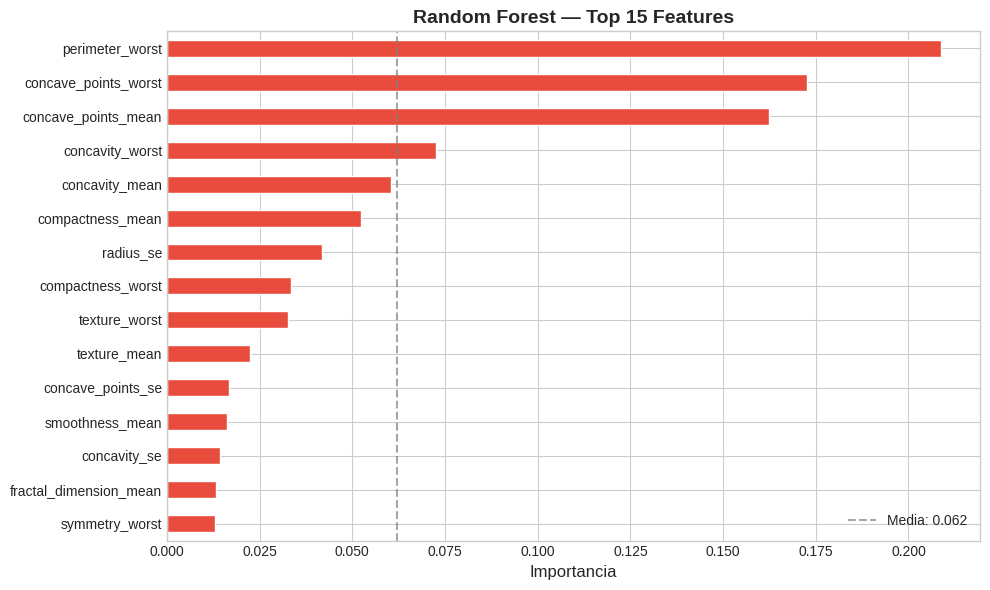

In [11]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot.barh(ax=ax, color=COLOR_M, edgecolor='white')
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Random Forest — Top 15 Features', fontsize=14, fontweight='bold')
ax.axvline(x=top15.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Media: {top15.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

---

## 6. XGBoost — Gradient Boosting

Árboles que se construyen **secuencialmente**: cada nuevo árbol corrige los errores del anterior.

`scale_pos_weight` compensa el desbalance de clases.

In [12]:
# Calcular ratio de desbalance
scale_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight = {scale_ratio:.2f}")
print(f"(Hay {scale_ratio:.1f}x más benignos que malignos)")

scale_pos_weight = 1.68
(Hay 1.7x más benignos que malignos)


In [13]:
xgb = XGBClassifier(
    scale_pos_weight=scale_ratio,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

cv_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=skf, scoring='accuracy')

print("Scores por fold:", [f"{s:.4f}" for s in cv_scores_xgb])
print(f"\nCV Accuracy: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

Scores por fold: ['0.9341', '0.9670', '0.9451', '0.9341', '0.9780']

CV Accuracy: 0.9516 ± 0.0179


In [14]:
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost — Test Set ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Benigno', 'Maligno']))

=== XGBoost — Test Set ===
              precision    recall  f1-score   support

     Benigno       0.97      1.00      0.99        72
     Maligno       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



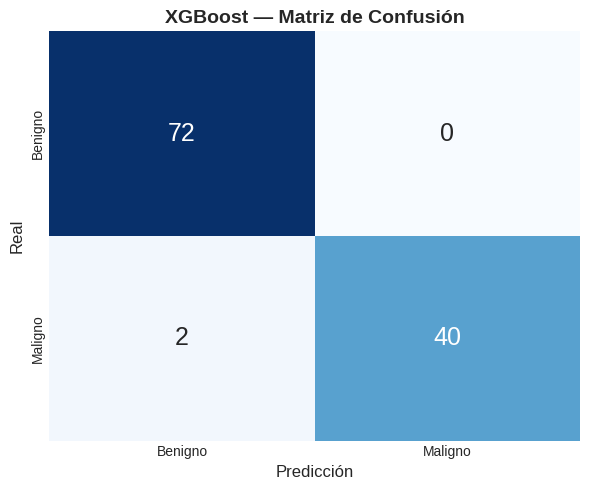

FP: 0
FN: 2  ← PELIGROSO


In [15]:
# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_xgb, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benigno', 'Maligno'],
    yticklabels=['Benigno', 'Maligno'],
    ax=ax, cbar=False,
    annot_kws={'size': 18}
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('XGBoost — Matriz de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"FP: {cm_xgb[0, 1]}")
print(f"FN: {cm_xgb[1, 0]}  ← PELIGROSO")

---

## 7. Comparación de modelos

Hora de poner todo en una tabla. Métricas que importan:

- **Accuracy**: % total de aciertos
- **Precision_M**: De los que dijo Maligno, ¿cuántos realmente lo eran?
- **Recall_M**: De los que realmente son Maligno, ¿cuántos detectó?
- **F1_M**: Balance entre Precision y Recall para Maligno
- **AUC_ROC**: Capacidad de discriminar entre clases (0.5 = azar, 1.0 = perfecto)

In [16]:
def eval_model(name, y_true, y_pred, y_proba):
    """Calcula métricas clave para un modelo."""
    return {
        'Modelo': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_M': precision_score(y_true, y_pred),
        'Recall_M': recall_score(y_true, y_pred),
        'F1_M': f1_score(y_true, y_pred),
        'AUC_ROC': roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    eval_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr),
    eval_model('Random Forest', y_test, y_pred_rf, y_proba_rf),
    eval_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb),
])

results.set_index('Modelo', inplace=True)
results.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen')

,Accuracy,Precision_M,Recall_M,F1_M,AUC_ROC
Modelo,,,,,
Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9947
Random Forest,0.9649,1.0000,0.9048,0.9500,0.9964
XGBoost,0.9825,1.0000,0.9524,0.9756,0.9931


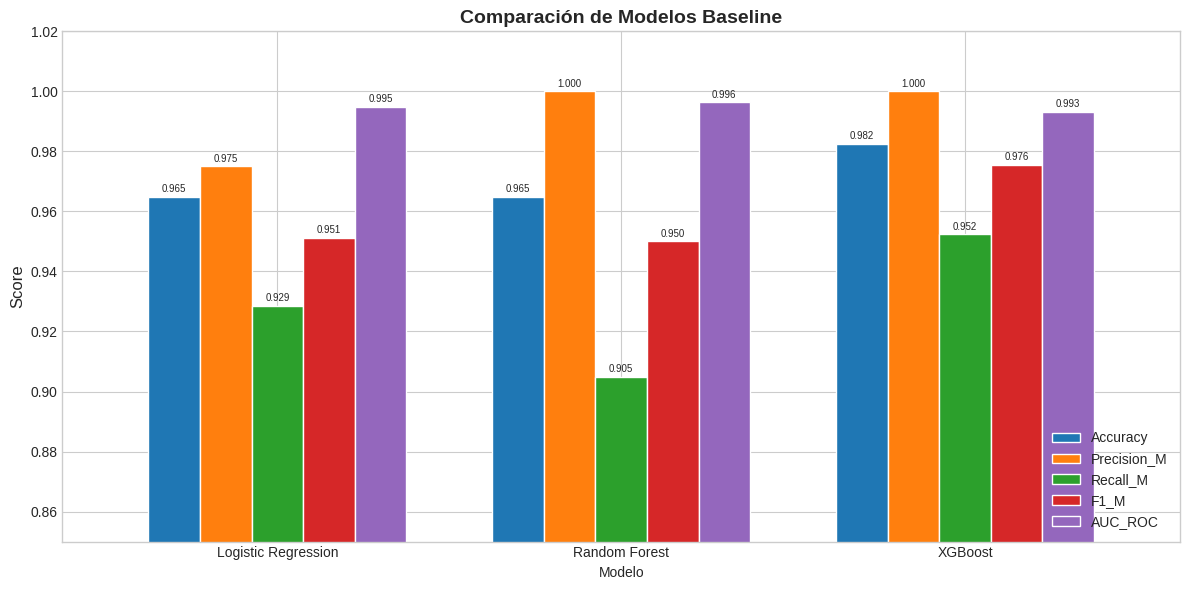

In [17]:
# Gráfico de comparación
fig, ax = plt.subplots(figsize=(12, 6))

results.plot.bar(
    ax=ax,
    rot=0,
    edgecolor='white',
    width=0.75
)

ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparación de Modelos Baseline', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.axhline(y=acc_dummy, color='gray', linestyle='--', alpha=0.5, label=f'Dummy: {acc_dummy:.2f}')

# Añadir valores sobre las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()

---

## 8. Guardar modelos

Guardamos los 3 modelos entrenados para analizarlos en el siguiente notebook.

In [18]:
models_dir = os.path.join(project_root, "models", "breast_cancer")
os.makedirs(models_dir, exist_ok=True)

models = {
    'logistic_regression.joblib': lr,
    'random_forest.joblib': rf,
    'xgboost.joblib': xgb,
}

for fname, model in models.items():
    path = os.path.join(models_dir, fname)
    joblib.dump(model, path)
    size_kb = os.path.getsize(path) / 1024
    print(f"Guardado: {fname} ({size_kb:.1f} KB)")

print(f"\nDirectorio: {models_dir}")

Guardado: logistic_regression.joblib (1.7 KB)
Guardado: random_forest.joblib (422.6 KB)
Guardado: xgboost.joblib (116.1 KB)

Directorio: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/breast_cancer


---

## Resumen

### Lo que construimos

| Modelo | Propósito |
|---|---|
| DummyClassifier | Piso: ~63% accuracy |
| Logistic Regression | Baseline lineal |
| Random Forest | Baseline no lineal |
| XGBoost | Baseline gradient boosting |

### Resultado

Accuracy alta (~95-97%). Todos los modelos destruyen al Dummy.

**PERO** accuracy no es suficiente. Necesitamos excavar en los errores:

- ¿Cuántos Falsos Negativos tiene cada modelo?
- ¿Qué tipo de tumores confunde?
- ¿Podemos reducir FN manipulando el umbral de decisión?

### Siguiente paso

**Notebook 04 — Autopsia del Modelo**: Analizamos *dónde* y *por qué* fallan estos modelos.